In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pygam import LinearGAM, s  # , te

plt.style.use("aslak")

rhoi = 917  # used to calculate rho_hat
g = 9.82
secperyear = 365.25 * 24 * 60 * 60
bdot = 0.11 * rhoi
T = -31


rho_surf = 333  # from S51hxct extrapolation to zero

symlog = lambda x, thres: np.sign(x) * (np.log(1 + np.abs(x) / thres))
symexp = lambda y, thres: np.sign(y) * thres * (np.exp(y) - 1)
forward_transform = lambda rho: -symlog(rhoi - rho, 1.0)
inverse_transform = lambda x: rhoi - symexp(-x, 1.0)


def concave_fit(zp, rhop, z, rhos=None, n_splines=20):
    X = zp.ravel()
    y = rhop.ravel()
    weights = np.ones_like(y)
    if rhos and np.min(X >= 0):
        X = np.append(0, X)
        y = np.append(rhos, y)
        weights = np.append(100.0, weights)  # should this be a parameter
    mygam = LinearGAM(s(0, n_splines=n_splines, constraints=["monotonic_inc", "concave"]), lam=1).fit(X, y, weights=weights)
    # z = np.arange(np.min(zp),np.max(zp),dz)
    rho = mygam.predict(z)
    rho[z > np.max(zp)] = np.nan  # do not extrapolate
    return rho


s51biasfun = lambda zz: 1 + (0.5 + 0.5 * np.tanh((zz - 45) / 20)) * 0.045
s51biasfun = lambda zz: 1

Load all the different profiles


In [ ]:
egsune = pd.read_csv("egrip/sune/egrip_density_iceeqdepth.txt", sep="\s+", comment="%", names=["z", "rho"], usecols=[0, 1])
egsune = egsune[egsune.z < 170]

In [ ]:
# this is from vas. I believe this is the same data that sune uses.
eg = pd.read_csv("egrip/egrip_density.txt", sep="\s+", header=0, names=["z", "rho"])
eg.sort_values(by="z", inplace=True)

In [ ]:
s6 = pd.read_excel("egrip/johannes_freitag/Density_EGRIP_S6_ExS5-1_ExS5-2.xlsx", header=0, names=["z", "rho"], usecols=[0, 1]).dropna()
s5_2 = pd.read_excel("egrip/johannes_freitag/Density_EGRIP_S6_ExS5-1_ExS5-2.xlsx", header=0, names=["z", "rho"], usecols=[2, 3]).dropna()
s5_1 = pd.read_excel("egrip/johannes_freitag/Density_EGRIP_S6_ExS5-1_ExS5-2.xlsx", header=0, names=["z", "rho"], usecols=[4, 5]).dropna()
s6.rho = s6.rho * 1000
s5_1.rho = s5_1.rho * 1000 * s51biasfun(s5_1.z)
s5_2.rho = s5_2.rho * 1000 * s51biasfun(s5_2.z)

s5_1.iloc[0]

s5_1hxct = pd.read_csv("egrip/johannes_freitag/Density_S5_1_HXCT.txt", sep="\s+").dropna()
s5_1hxct = s5_1hxct.rename(columns={"avgdepth_m": "z", "avg_density": "rho"})
s5_1hxct.rho = s5_1hxct.rho * 1000

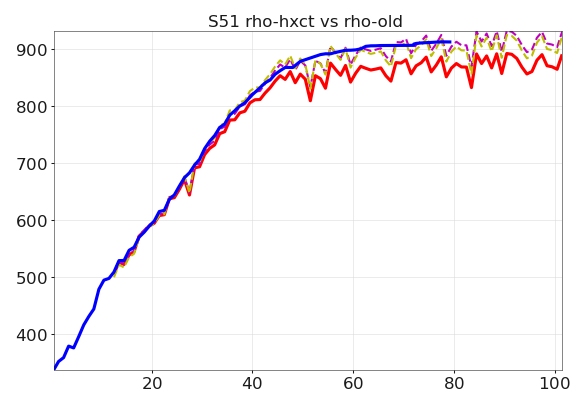

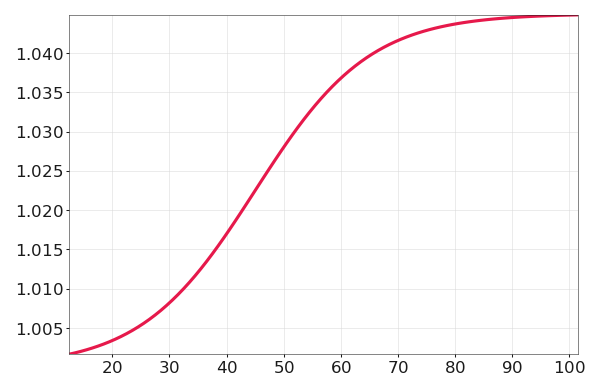

In [ ]:
# plt.plot(s5_1.z,s5_1.rho,'r')
test_biasfun = lambda zz: 1 + (0.5 + 0.5 * np.tanh((zz - 45) / 20)) * 0.045
plt.plot(s5_1.z, s5_1.rho, "r")
plt.plot(s5_1.z, s5_1.rho * test_biasfun(s5_1.z), "m--", lw=1)
plt.plot(s5_1.z, s5_1.rho * (1 + (s5_1.rho - 600) * 0.05 / 400), "y--", lw=1)
plt.plot(s5_1hxct.z, s5_1hxct.rho, "b")
plt.title("S51 rho-hxct vs rho-old ")
plt.show()
plt.plot(s5_1.z, test_biasfun(s5_1.z))
plt.show()

In [ ]:
# save all the profiles on this interval.
z = np.arange(0, 100, 1) * 1.0
EGsmoothrho = concave_fit(eg.z.values, eg.rho.values, z)
S6smoothrho = concave_fit(s6.z.values, s6.rho.values, z)
# the s5 cores dont go to the surface. Make them go through rhos
S51smoothrho = concave_fit(s5_1.z.values, s5_1.rho.values, z, rho_surf)
S52smoothrho = concave_fit(s5_2.z.values, s5_2.rho.values, z, rho_surf)
EGsuneout = np.interp(z, egsune.z.values, egsune.rho.values)
S51hxctsmoothrho = concave_fit(s5_1hxct.z.values, s5_1hxct.rho.values, z, rho_surf)

df = pd.DataFrame(
    {"z": z, "EG": EGsmoothrho, "S6": S6smoothrho, "S5_1": S51smoothrho, "S5_2": S52smoothrho, "EG-sune": EGsuneout, "S5_1hxct": S51hxctsmoothrho}
)

df.to_csv("egrip/smoothed_densityprofiles_AG.csv", index=False)

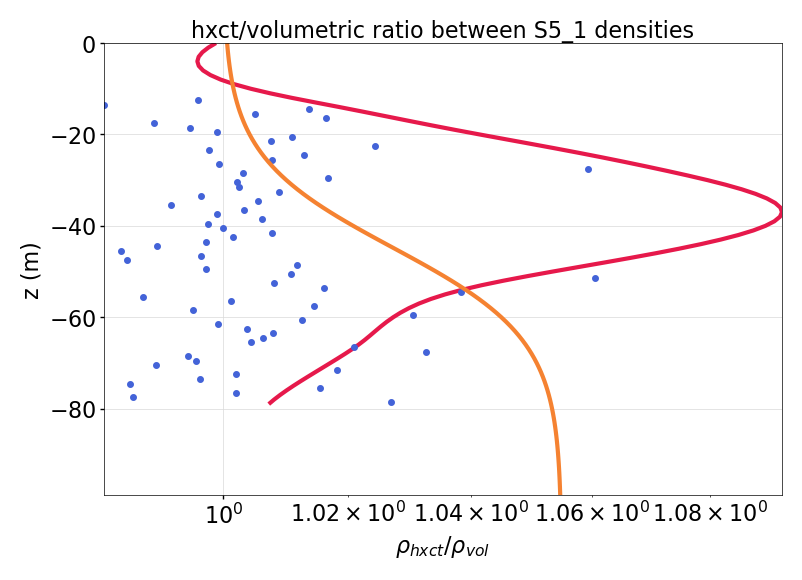

In [ ]:
bias = S51hxctsmoothrho / S52smoothrho


plt.semilogx(bias, -z)
# plt.plot(s5_1hxct.rho/np.interp(s5_1hxct.z,z,S52smoothrho),-s5_1hxct.z,'.')
plt.plot(np.interp(s5_1.z, z, S51hxctsmoothrho) / s5_1.rho, -s5_1.z, ".")

plt.title("hxct/volumetric ratio between S5_1 densities")
plt.xlabel(r"$\rho_{hxct}/\rho_{vol}$")
plt.ylabel("z (m)")
plt.plot(1 + (0.5 + 0.5 * np.tanh((z - 45) / 20)) * 0.055, -z)
s51biasfun = lambda zz: 1 + (0.5 + 0.5 * np.tanh((zz - 45) / 20)) * 0.055

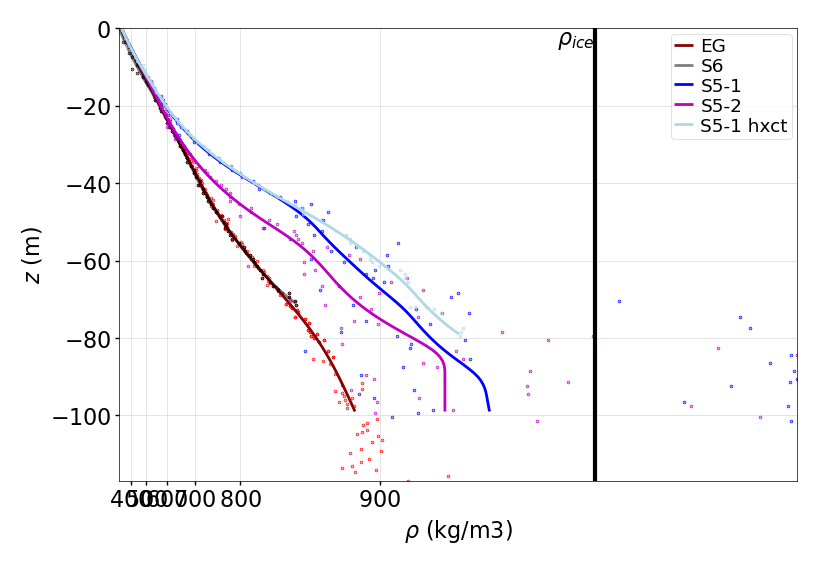

In [ ]:
egmult = 1
plt.plot(eg.rho * egmult, -eg.z, "r.", ms=0.5)
# plt.plot(egsune.rho,-egsune.z,'r-',label='EG.sune',lw=1)
plt.plot(EGsmoothrho * egmult, -z, "-", color="darkred", label="EG", lw=1, ms=0.5)
plt.plot(s6.rho * egmult, -s6.z, "k.", ms=0.51)
plt.plot(S6smoothrho * egmult, -z, "k-", label="S6", lw=1, alpha=0.5)


plt.plot(s5_1.rho, -s5_1.z, "b.", lw=0.1, ms=0.5)
plt.plot(S51smoothrho, -z, "-", color="b", label="S5-1", lw=1)

plt.plot(s5_2.rho, -s5_2.z, "m.", lw=0.1, ms=0.5)
plt.plot(S52smoothrho, -z, "-", color="m", label="S5-2", lw=1)


plt.plot(S51hxctsmoothrho, -z, "-", color="lightblue", label="S5-1 hxct", lw=1)
plt.plot(s5_1hxct.rho, -s5_1hxct.z, ".", color="lightblue", ms=0.5)

plt.axvline(rhoi, color="k")
plt.text(rhoi, 0, "$\\rho_{ice}$", va="top", ha="right")

plt.xscale("function", functions=(forward_transform, inverse_transform))
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# plt.gca().xaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel("$\\rho$ (kg/m3)")
plt.ylabel("$z$ (m)")
plt.legend()

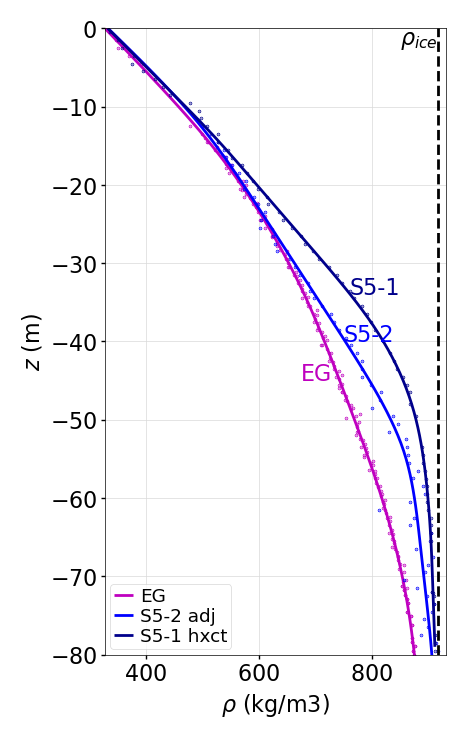

In [ ]:
egmult = 1
plt.figure(figsize=[2.9 * 0.6, 6 * 0.6])
color = "m"
plt.plot(eg.rho * egmult, -eg.z, ".", color=color, ms=0.5)
# plt.plot(egsune.rho,-egsune.z,'r-',label='EG.sune',lw=1)
plt.plot(EGsmoothrho * egmult, -z, "-", color=color, label="EG", lw=1, ms=0.5)
# plt.plot(s6.rho*egmult,-s6.z,'k.',ms=0.5)
# plt.plot(S6smoothrho*egmult,-z,'k-',label='S6',lw=1,alpha=0.3)

plt.text(730, -45, "EG", color=color, ha="right")


# plt.plot(s5_1.rho,-s5_1.z,'b.',lw=0.1,ms=0.5)
# plt.plot(S51smoothrho,-z,'-',color='b',label='S5-1',lw=1)

color = "blue"
plt.plot(s5_2.rho, -s5_2.z, ".", color=color, lw=0.1, ms=0.5)
plt.plot(S52smoothrho, -z, "-", color=color, label="S5-2 adj", lw=1)
plt.text(750, -40, "S5-2", color=color)

color = "darkblue"
plt.plot(S51hxctsmoothrho, -z, "-", color=color, label="S5-1 hxct", lw=1)
plt.plot(s5_1hxct.rho, -s5_1hxct.z, ".", color=color, ms=0.5)
plt.text(760, -34, "S5-1", color=color)

plt.axvline(rhoi, color="k", linestyle="--", linewidth=1)
plt.text(rhoi, 0, "$\\rho_{ice}$", va="top", ha="right")

# plt.xscale('function', functions=(forward_transform, inverse_transform))
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# plt.gca().xaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel("$\\rho$ (kg/m3)")
plt.ylabel("$z$ (m)")
plt.legend()
plt.ylim([-80, 0])

plt.savefig("egrip/egrip_densityprofiles_biasadj.png", bbox_inches="tight")

In [ ]:
np.interp(830, S51hxctsmoothrho, z) - np.interp(830, EGsmoothrho * egmult, z)

-21.75883282925855

332.8204494959213

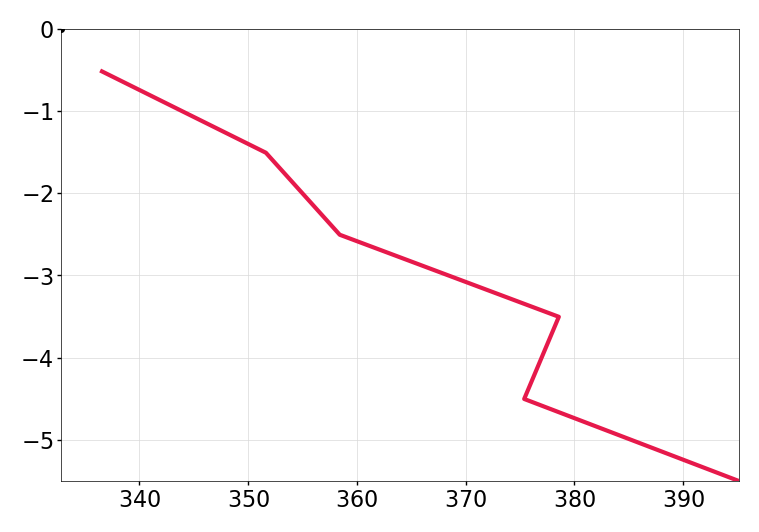

In [ ]:
ix = s5_1hxct.z < 6
p = np.polyfit(s5_1hxct.z[ix], s5_1hxct.rho[ix], 1)
rhos = p[1]
plt.plot(s5_1hxct.rho[ix], -s5_1hxct.z[ix])
plt.plot(p[1], 0, "k.")
rhos